# Importação de Bibliotecas

In [25]:
import mysql.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import mysql
from dotenv import load_dotenv
import os
import numpy as np

# Inicialização da Conexão com o Banco de Dados

In [26]:

## Carrega as variáveis do arquivo .env
load_dotenv()

## Configura a conexão (sem executar nada ainda)
conexao = mysql.connector.connect(
    host="localhost",
    user="root",
    password=os.getenv('DB_PASS'),
    database="vendas_ecommerce"
)

## ativando o cursor

cursor = conexao.cursor()
print("Banco conectado!")

Banco conectado!


# Realização de 5 Consultas Estratégicas

In [27]:
#  Top 5 Categorias por Receita
cursor = conexao.cursor()
query = """
SELECT p.product_category_name, SUM(py.payment_value) AS receita_total
FROM order_payments py
JOIN order_items oi ON py.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY receita_total DESC
LIMIT 5
"""
cursor.execute(query)
resultados = cursor.fetchall()

print("--- TOP 5 CATEGORIAS POR RECEITA ---")
for linha in resultados:
    print(f"Categoria: {linha[0]} | Total: R$ {linha[1]:.2f}")
cursor.close()

--- TOP 5 CATEGORIAS POR RECEITA ---
Categoria: beleza_saude | Total: R$ 1475959.99
Categoria: cama_mesa_banho | Total: R$ 1430846.62
Categoria: relogios_presentes | Total: R$ 1328570.91
Categoria: esporte_lazer | Total: R$ 1188257.52
Categoria: informatica_acessorios | Total: R$ 1135342.78


True

In [28]:
# Estados com Maior Média de Atraso na Entrega
cursor = conexao.cursor()
query = """
SELECT c.customer_state, 
       AVG(DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date)) AS media_atraso
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY media_atraso DESC
"""
cursor.execute(query)
resultados = cursor.fetchall()

print("--- MÉDIA DE ATRASO POR ESTADO (EM DIAS) ---")
for linha in resultados:
    print(f"Estado: {linha[0]} | Média: {linha[1]:.2f} dias")
cursor.close()

--- MÉDIA DE ATRASO POR ESTADO (EM DIAS) ---
Estado: AL | Média: -8.71 dias
Estado: MA | Média: -9.57 dias
Estado: SE | Média: -10.02 dias
Estado: ES | Média: -10.50 dias
Estado: BA | Média: -10.79 dias
Estado: CE | Média: -10.80 dias
Estado: MS | Média: -11.05 dias
Estado: SP | Média: -11.08 dias
Estado: PI | Média: -11.31 dias
Estado: SC | Média: -11.51 dias
Estado: RJ | Média: -11.77 dias
Estado: DF | Média: -12.05 dias
Estado: TO | Média: -12.13 dias
Estado: GO | Média: -12.19 dias
Estado: MG | Média: -13.24 dias
Estado: PB | Média: -13.26 dias
Estado: PE | Média: -13.29 dias
Estado: PR | Média: -13.31 dias
Estado: RN | Média: -13.65 dias
Estado: RS | Média: -13.91 dias
Estado: PA | Média: -14.07 dias
Estado: MT | Média: -14.36 dias
Estado: RR | Média: -17.29 dias
Estado: AM | Média: -19.57 dias
Estado: AP | Média: -19.69 dias
Estado: RO | Média: -20.10 dias
Estado: AC | Média: -20.72 dias


True

In [29]:
# Contagem de Clientes Recorrentes
cursor = conexao.cursor()
query = """
SELECT COUNT(*) FROM (
    SELECT customer_unique_id
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    GROUP BY customer_unique_id
    HAVING COUNT(o.order_id) > 1
) AS subquery
"""
cursor.execute(query)
resultado = cursor.fetchone()

print(f"Total de clientes que compraram mais de uma vez: {resultado[0]}")
cursor.close()

Total de clientes que compraram mais de uma vez: 2997


True

In [30]:
# Preferência de Pagamento em Compras de Alto Valor (Maior que 500)
cursor = conexao.cursor()
query = """
SELECT payment_type, COUNT(order_id), AVG(payment_installments)
FROM order_payments
WHERE payment_value > 500
GROUP BY payment_type
"""
cursor.execute(query)
resultados = cursor.fetchall()

print("--- PAGAMENTOS EM COMPRAS ACIMA DE R$ 500 ---")
for linha in resultados:
    print(f"Tipo: {linha[0]} | Qtd Pedidos: {linha[1]} | Média Parcelas: {linha[2]:.1f}")
cursor.close()

--- PAGAMENTOS EM COMPRAS ACIMA DE R$ 500 ---
Tipo: credit_card | Qtd Pedidos: 3451 | Média Parcelas: 7.2
Tipo: boleto | Qtd Pedidos: 678 | Média Parcelas: 1.0
Tipo: voucher | Qtd Pedidos: 38 | Média Parcelas: 1.0
Tipo: debit_card | Qtd Pedidos: 44 | Média Parcelas: 1.0


True

In [31]:
# Relação entre Nota de Avaliação e Valor do Frete

cursor = conexao.cursor()
query = """
SELECT r.review_score, AVG(oi.freight_value)
FROM order_reviews r
JOIN order_items oi ON r.order_id = oi.order_id
GROUP BY r.review_score
ORDER BY r.review_score DESC
"""
cursor.execute(query)
resultados = cursor.fetchall()

print("--- MÉDIA DE FRETE POR NOTA DE AVALIAÇÃO ---")
for linha in resultados:
    print(f"Nota: {linha[0]} | Frete Médio: R$ {linha[1]:.2f}")
cursor.close()

--- MÉDIA DE FRETE POR NOTA DE AVALIAÇÃO ---
Nota: 5 | Frete Médio: R$ 19.73
Nota: 4 | Frete Médio: R$ 20.18
Nota: 3 | Frete Médio: R$ 20.28
Nota: 2 | Frete Médio: R$ 21.08
Nota: 1 | Frete Médio: R$ 21.46


True

# Análise Estatística Descritiva

Análise Estatística Descritiva: Valores de Pagamento
Nesta seção, realizei o cálculo de tendência central (média e mediana) e identificamos a dispersão dos dados através de quartis e detecção de outliers.

In [32]:
cursor = conexao.cursor()

#  Definir a query para buscar os valores de pagamento
query = "SELECT payment_value FROM order_payments"

#  Executar
cursor.execute(query)

#  Obter resultados e converter para uma lista de números
resultados = cursor.fetchall()
valores = [float(linha[0]) for linha in resultados]

#  Realizar os cálculos estatísticos
media = np.mean(valores)
mediana = np.median(valores)
q1 = np.percentile(valores, 25) # 1º Quartil
q3 = np.percentile(valores, 75) # 3º Quartil
iqr = q3 - q1 # Intervalo Interquartil

# Cálculo de Outliers (Regra do 1.5 * IQR)
limite_inferior = q1 - (1.5 * iqr)
limite_superior = q3 + (1.5 * iqr)
outliers = [v for v in valores if v < limite_inferior or v > limite_superior]

# Exibir os resultados
print(f"--- Estatística de Pagamentos ---")
print(f"Média: R$ {media:.2f}")
print(f"Mediana: R$ {mediana:.2f}")
print(f"Q1 (25%): R$ {q1:.2f}")
print(f"Q3 (75%): R$ {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Limite Superior para Outliers: R$ {limite_superior:.2f}")
print(f"Quantidade de Outliers: {len(outliers)}")

# Fechar
cursor.close()

--- Estatística de Pagamentos ---
Média: R$ 158.33
Mediana: R$ 103.35
Q1 (25%): R$ 60.05
Q3 (75%): R$ 175.13
IQR: 115.08
Limite Superior para Outliers: R$ 347.75
Quantidade de Outliers: 7770


True

# Exploração Gráfica de Faturamento: Histograma e Boxplot

C:\Users\bruno\AppData\Local\Temp\ipykernel_22820\1921473040.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexao)


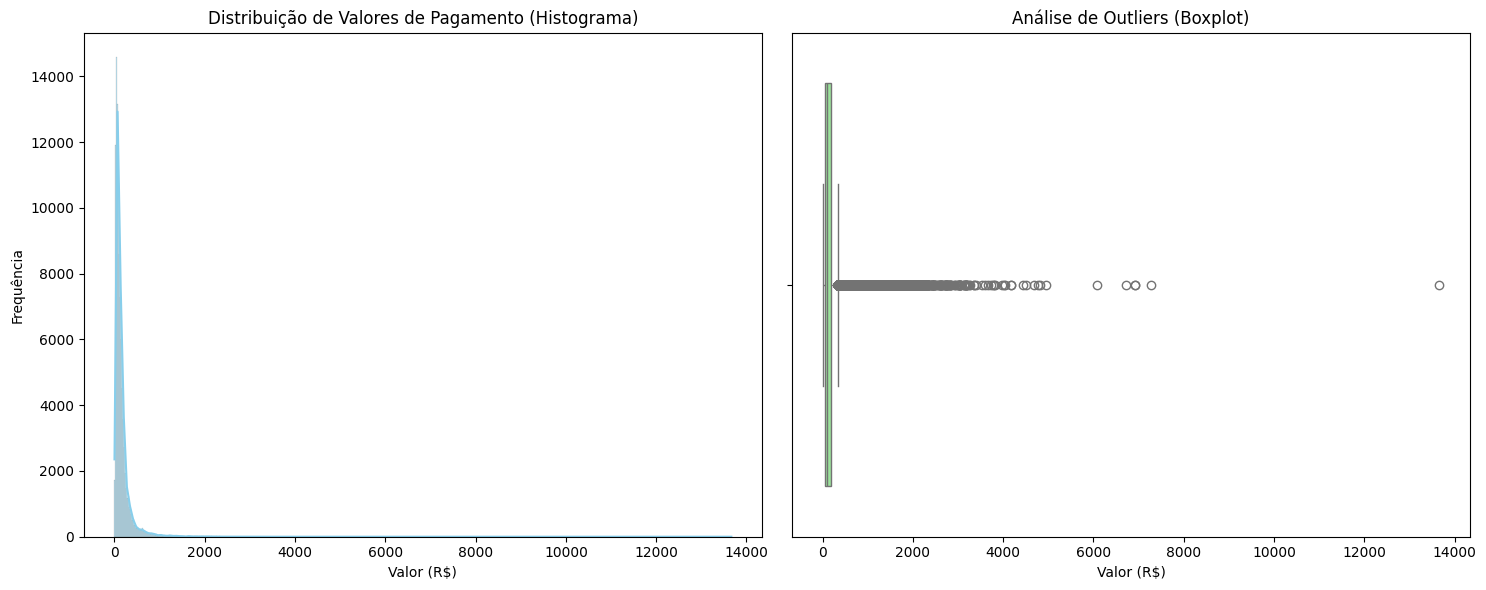

In [ ]:

query = "SELECT payment_value FROM order_payments"
df = pd.read_sql(query, conexao)

#  
plt.figure(figsize=(15, 6))

#  GRÁFICO 1: HISTOGRAMA 
plt.subplot(1, 2, 1) # Posição 1
sns.histplot(df['payment_value'], kde=True, color='skyblue')
plt.title('Distribuição de Valores de Pagamento (Histograma)')
plt.xlabel('Valor (R$)')
plt.ylabel('Frequência')

#  GRÁFICO 2: BOXPLOT 
plt.subplot(1, 2, 2) # Posição 2
sns.boxplot(x=df['payment_value'], color='lightgreen')
plt.title('Análise de Outliers (Boxplot)')
plt.xlabel('Valor (R$)')

# 4. Ajustar layout e exibir
plt.tight_layout()
plt.show()

# 5. Fechar conexão
conexao.close()

A análise visual revela um cenário típico de varejo online: um alto volume de pedidos com tickets baixos e uma presença significativa de outliers no faturamento. Enquanto a maioria das vendas se concentra abaixo de R$ 500, identifiquei transações excepcionais que chegam a superar R$ 13.000, o que sugere a necessidade de estratégias diferentes para produtos de entrada e produtos premium.